In [1]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report


## Feature scaling and feature selection

In [2]:
students_df = pd.read_csv("data.csv", sep = ';')
students_df.columns = [(column.lower()).strip().replace(" ","_") for column in students_df.columns]

In [3]:
students = students_df[["course", 
                     "daytime/evening_attendance", 
                     "application_mode", 
                     "application_order", 
                     "age_at_enrollment", 
                     "admission_grade", 
                     "curricular_units_1st_sem_(approved)", 
                     "curricular_units_1st_sem_(enrolled)", 
                     "curricular_units_1st_sem_(evaluations)",
                     "curricular_units_1st_sem_(grade)", 
                     "tuition_fees_up_to_date",
                     "target"]]

In [4]:
students.head(3)

,course,daytime/evening_attendance,application_mode,application_order,age_at_enrollment,admission_grade,curricular_units_1st_sem_(approved),curricular_units_1st_sem_(enrolled),curricular_units_1st_sem_(evaluations),curricular_units_1st_sem_(grade),tuition_fees_up_to_date,target
0,171,1,17,5,20,127.3,0,0,0,0.0,1,Dropout
1,9254,1,15,1,19,142.5,6,6,6,14.0,0,Graduate
2,9070,1,1,5,19,124.8,0,6,0,0.0,0,Dropout


In [5]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   course                                  4424 non-null   int64  
 1   daytime/evening_attendance              4424 non-null   int64  
 2   application_mode                        4424 non-null   int64  
 3   application_order                       4424 non-null   int64  
 4   age_at_enrollment                       4424 non-null   int64  
 5   admission_grade                         4424 non-null   float64
 6   curricular_units_1st_sem_(approved)     4424 non-null   int64  
 7   curricular_units_1st_sem_(enrolled)     4424 non-null   int64  
 8   curricular_units_1st_sem_(evaluations)  4424 non-null   int64  
 9   curricular_units_1st_sem_(grade)        4424 non-null   float64
 10  tuition_fees_up_to_date                 4424 non-null   int64  
 11  ta

In [6]:
students.shape

(4424, 12)

In [7]:
for column in students:
    print (f"Column {column}:", students[column].nunique())

Column course: 17
Column daytime/evening_attendance: 2
Column application_mode: 18
Column application_order: 8
Column age_at_enrollment: 46
Column admission_grade: 620
Column curricular_units_1st_sem_(approved): 23
Column curricular_units_1st_sem_(enrolled): 23
Column curricular_units_1st_sem_(evaluations): 35
Column curricular_units_1st_sem_(grade): 805
Column tuition_fees_up_to_date: 2
Column target: 3


## Train Test Split

In [8]:
copy_df = students[['course', 
                 'daytime/evening_attendance', 
                 'application_mode', 
                 'application_order', 
                 'tuition_fees_up_to_date']]

In [9]:
features = students.drop(columns = ["target"])
target = students["target"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, stratify=target, random_state=0)

## Model evaluation

### 1. Manual hyperparameter tunning

#### 1.1 max_depth=20, n_estimators=100

In [11]:
gb_classif_m1 = GradientBoostingClassifier(max_depth=20,
                                   n_estimators=100)

In [12]:
gb_classif_m1.fit(X_train, y_train)

,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",20
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to c

In [13]:
y_pred_test_m1 = gb_classif_m1.predict(X_test)
y_pred_train_m1 = gb_classif_m1.predict(X_train)

print(f"accuracy {accuracy_score(y_test, y_pred_test_m1)*100: .2f}")
print(f"accuracy_train {accuracy_score(y_train, y_pred_train_m1)*100: .2f}")

print(f"recall {recall_score(y_test, y_pred_test_m1, average='macro'): .2f}")
print(f"F1-score {f1_score(y_test, y_pred_test_m1, average='macro'): .2f}")
print(f"Precision_score {precision_score(y_test, y_pred_test_m1, average='macro'): .2f}")

accuracy  67.34
accuracy_train  100.00
recall  0.59
F1-score  0.59
Precision_score  0.60


In [14]:
print(classification_report(y_pred = y_pred_test_m1, y_true = y_test))

              precision    recall  f1-score   support

     Dropout       0.70      0.68      0.69       284
    Enrolled       0.35      0.27      0.31       159
    Graduate       0.74      0.81      0.77       442

    accuracy                           0.67       885
   macro avg       0.60      0.59      0.59       885
weighted avg       0.66      0.67      0.66       885



**Conclusion**

Based on amount of 'accuracy_train' matricw e've got overfitting model. To fix it we can try to tune parameters manually.

#### 1.2 max_depth=3, n_estimators=100

To decrease overfitting we can decrease max_depth from 20 to 3 and we will get higher accuracy

In [15]:
gb_classif_m2 = GradientBoostingClassifier(max_depth=3,
                                   n_estimators=100)

In [16]:
gb_classif_m2.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [17]:
y_pred_test_m2 = gb_classif_m2.predict(X_test)
y_pred_train_m2 = gb_classif_m2.predict(X_train)

print(f"accuracy {accuracy_score(y_test, y_pred_test_m2)*100: .2f}")
print(f"accuracy_train {accuracy_score(y_train, y_pred_train_m2)*100: .2f}")

print(f"recall {recall_score(y_test, y_pred_test_m2, average='macro'): .2f}")
print(f"F1-score {f1_score(y_test, y_pred_test_m2, average='macro'): .2f}")
print(f"Precision_score {precision_score(y_test, y_pred_test_m2, average='macro'): .2f}")

accuracy  75.59
accuracy_train  78.21
recall  0.67
F1-score  0.67
Precision_score  0.71


In [18]:
print(classification_report(y_pred = y_pred_test_m2, y_true = y_test))

              precision    recall  f1-score   support

     Dropout       0.77      0.76      0.76       284
    Enrolled       0.56      0.33      0.42       159
    Graduate       0.78      0.90      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.67       885
weighted avg       0.74      0.76      0.74       885



### 2. Hyperparameter Tuning using GridSearch

#### 2.1 Two parameters: max_depth, n_estimators

Now we need to calculate the best model parameters to increase performance. 

Hyperparameters defenotion

In [19]:
parameter_grid = {"max_depth": [3, 20],
                  "n_estimators": [1, 100]}

gb_classif = GradientBoostingClassifier(random_state=123)

confidence_level = 0.95
folds = 10

Grid search running

In [20]:
grid_search = GridSearchCV(gb_classif, param_grid=parameter_grid, cv=folds, verbose=10, error_score='raise')

start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {grid_search.best_params_}")
print(f"The best CV accuracy is: {grid_search.best_score_: .4f}")

results_gs_df = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False)

gs_mean_score = results_gs_df.iloc[0,-3]
gs_sem = results_gs_df.iloc[0,-2] / np.sqrt(folds)

gs_tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
gs_lower_bound = gs_mean_score - ( gs_tc * gs_sem )
gs_upper_bound = gs_mean_score + ( gs_tc * gs_sem )

print(f"The 'accuracy' confidence interval for the best combination of hyperparameters is: \
    ({gs_lower_bound: .4f}, {gs_mean_score: .4f}, {gs_upper_bound: .4f}) ")

Fitting 10 folds for each of 4 candidates, totalling 40 fits
[CV 1/10; 1/4] START max_depth=3, n_estimators=1................................
[CV 1/10; 1/4] END .max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 2/10; 1/4] START max_depth=3, n_estimators=1................................
[CV 2/10; 1/4] END .max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 3/10; 1/4] START max_depth=3, n_estimators=1................................
[CV 3/10; 1/4] END .max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 4/10; 1/4] START max_depth=3, n_estimators=1................................
[CV 4/10; 1/4] END .max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 5/10; 1/4] START max_depth=3, n_estimators=1................................
[CV 5/10; 1/4] END .max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 6/10; 1/4] START max_depth=3, n_estimators=1................................
[CV 6/10; 1/4] END .max_depth=3, n_estimators=1;

In [21]:
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print("\n")
print(f"accuracy {accuracy_score(y_test, y_pred_test)*100: .2f}")
print(f"accuracy_train {accuracy_score(y_train, y_pred_train)*100: .2f}")

print(f"recall {recall_score(y_test, y_pred_test, average='macro'): .2f}")
print(f"F1-score {f1_score(y_test, y_pred_test, average='macro'): .2f}")
print(f"Precision_score {precision_score(y_test, y_pred_test, average='macro'): .2f}")
print("\n")



accuracy  75.59
accuracy_train  78.21
recall  0.67
F1-score  0.67
Precision_score  0.71




In [22]:
print(classification_report(y_pred = y_pred_test, y_true = y_test))

              precision    recall  f1-score   support

     Dropout       0.77      0.76      0.76       284
    Enrolled       0.56      0.33      0.42       159
    Graduate       0.78      0.90      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.67       885
weighted avg       0.74      0.76      0.74       885



#### 2.3 Three parameters: max_depth, n_estimators, learning_rate: [0.0, 0.2]

Let's add "learning_rate" parameter to amplify model performance

In [23]:
parameter_grid_1 = {"max_depth": [3, 20],
                  "n_estimators": [1, 100],
                   "learning_rate": [0.0, 0.2]}

gb_classif_1 = GradientBoostingClassifier(random_state=123)

confidence_level_1 = 0.95
folds = 10

In [24]:
grid_search_1 = GridSearchCV(gb_classif_1, param_grid=parameter_grid_1, cv=folds, verbose=10, error_score='raise')

start_time = time.time()
grid_search_1.fit(X_train, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {grid_search_1.best_params_}")
print(f"The best CV accuracy is: {grid_search_1.best_score_: .4f}")

res_gs_df = pd.DataFrame(grid_search_1.cv_results_).sort_values(by="mean_test_score", ascending=False)

gridsearch_mean_score = res_gs_df.iloc[0,-3]
gridsearch_sem = res_gs_df.iloc[0,-2] / np.sqrt(folds)

gridsearch_tc = st.t.ppf(1-((1-confidence_level_1)/2), df=folds-1)
gs_lower_b = gridsearch_mean_score - ( gridsearch_tc * gridsearch_sem )
gs_upper_b = gridsearch_mean_score + ( gridsearch_tc * gridsearch_sem )

print(f"The 'accuracy' confidence interval for the best combination of hyperparameters is: \
    ({gs_lower_b: .4f}, {gridsearch_mean_score: .4f}, {gs_upper_b: .4f}) ")


Fitting 10 folds for each of 8 candidates, totalling 80 fits
[CV 1/10; 1/8] START learning_rate=0.0, max_depth=3, n_estimators=1.............
[CV 1/10; 1/8] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 2/10; 1/8] START learning_rate=0.0, max_depth=3, n_estimators=1.............
[CV 2/10; 1/8] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 3/10; 1/8] START learning_rate=0.0, max_depth=3, n_estimators=1.............
[CV 3/10; 1/8] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 4/10; 1/8] START learning_rate=0.0, max_depth=3, n_estimators=1.............
[CV 4/10; 1/8] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 5/10; 1/8] START learning_rate=0.0, max_depth=3, n_estimators=1.............
[CV 5/10; 1/8] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 6/10; 1/8] START learning_rate=0.0,

In [25]:
best_model_1 = grid_search_1.best_estimator_
y_pred_test_1 = best_model_1.predict(X_test)
y_pred_train_1 = best_model_1.predict(X_train)

print("\n")
print(f"accuracy {accuracy_score(y_test, y_pred_test_1)*100: .2f}")
print(f"accuracy_train {accuracy_score(y_train, y_pred_train_1)*100: .2f}")

print(f"recall {recall_score(y_test, y_pred_test_1, average='macro'): .2f}")
print(f"F1-score {f1_score(y_test, y_pred_test_1, average='macro'): .2f}")
print(f"Precision_score {precision_score(y_test, y_pred_test_1, average='macro'): .2f}")
print("\n")



accuracy  74.69
accuracy_train  82.20
recall  0.66
F1-score  0.67
Precision_score  0.68




In [26]:
print(classification_report(y_pred = y_pred_test_1, y_true = y_test))

              precision    recall  f1-score   support

     Dropout       0.75      0.76      0.76       284
    Enrolled       0.49      0.34      0.40       159
    Graduate       0.80      0.88      0.84       442

    accuracy                           0.75       885
   macro avg       0.68      0.66      0.67       885
weighted avg       0.73      0.75      0.73       885



#### 2.4 Three parameters: max_depth, n_estimators, learning_rate: [0.0, 0.15, 0.2]

In [27]:
parameter_grid_2 = {"max_depth": [3, 20],
                  "n_estimators": [1, 100],
                   "learning_rate": [0.0, 0.15, 0.2]}

gb_classif_2 = GradientBoostingClassifier(random_state=123)

confidence_level_2 = 0.95
folds = 10

In [28]:
grid_search_2 = GridSearchCV(gb_classif_2, param_grid=parameter_grid_2, cv=folds, verbose=10, error_score='raise')

start_time = time.time()
grid_search_2.fit(X_train, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {grid_search_2.best_params_}")
print(f"The best CV accuracy is: {grid_search_2.best_score_: .4f}")

res_gs_df = pd.DataFrame(grid_search_2.cv_results_).sort_values(by="mean_test_score", ascending=False)

gridsearch_mean_score = res_gs_df.iloc[0,-3]
gridsearch_sem = res_gs_df.iloc[0,-2] / np.sqrt(folds)

gridsearch_tc = st.t.ppf(1-((1-confidence_level_2)/2), df=folds-1)
gs_lower_b = gridsearch_mean_score - ( gridsearch_tc * gridsearch_sem )
gs_upper_b = gridsearch_mean_score + ( gridsearch_tc * gridsearch_sem )

print(f"The 'accuracy' confidence interval for the best combination of hyperparameters is: \
    ({gs_lower_b: .4f}, {gridsearch_mean_score: .4f}, {gs_upper_b: .4f}) ")

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV 1/10; 1/12] START learning_rate=0.0, max_depth=3, n_estimators=1............
[CV 1/10; 1/12] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 2/10; 1/12] START learning_rate=0.0, max_depth=3, n_estimators=1............
[CV 2/10; 1/12] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 3/10; 1/12] START learning_rate=0.0, max_depth=3, n_estimators=1............
[CV 3/10; 1/12] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 4/10; 1/12] START learning_rate=0.0, max_depth=3, n_estimators=1............
[CV 4/10; 1/12] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 5/10; 1/12] START learning_rate=0.0, max_depth=3, n_estimators=1............
[CV 5/10; 1/12] END learning_rate=0.0, max_depth=3, n_estimators=1;, score=0.500 total time=   0.0s
[CV 6/10; 1/12] START learning_r

In [29]:
best_model_2 = grid_search_2.best_estimator_
y_pred_test_2 = best_model_2.predict(X_test)
y_pred_train_2 = best_model_2.predict(X_train)

print("\n")
print(f"accuracy {accuracy_score(y_test, y_pred_test_2)*100: .2f}")
print(f"accuracy_train {accuracy_score(y_train, y_pred_train_2)*100: .2f}")

print(f"recall {recall_score(y_test, y_pred_test_2, average='macro'): .2f}")
print(f"F1-score {f1_score(y_test, y_pred_test_2, average='macro'): .2f}")
print(f"Precision_score {precision_score(y_test, y_pred_test_2, average='macro'): .2f}")
print("\n")



accuracy  74.58
accuracy_train  80.16
recall  0.66
F1-score  0.66
Precision_score  0.68




In [30]:
print(classification_report(y_pred = y_pred_test_2, y_true = y_test))

              precision    recall  f1-score   support

     Dropout       0.75      0.75      0.75       284
    Enrolled       0.50      0.33      0.40       159
    Graduate       0.80      0.89      0.84       442

    accuracy                           0.75       885
   macro avg       0.68      0.66      0.66       885
weighted avg       0.73      0.75      0.73       885



In [31]:
print("GridSearch ('max_depth': 3, 'n_estimators': 100)")
print(classification_report(y_pred = y_pred_test, y_true = y_test))
print("---")
print("\n")
print("GridSearch ('learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100)")
print(classification_report(y_pred = y_pred_test_1, y_true = y_test))
print("---")
print("\n")
print("GridSearch (learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 100)")
print(classification_report(y_pred = y_pred_test_2, y_true = y_test))
print("---")

GridSearch ('max_depth': 3, 'n_estimators': 100)
              precision    recall  f1-score   support

     Dropout       0.77      0.76      0.76       284
    Enrolled       0.56      0.33      0.42       159
    Graduate       0.78      0.90      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.67       885
weighted avg       0.74      0.76      0.74       885

---


GridSearch ('learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100)
              precision    recall  f1-score   support

     Dropout       0.75      0.76      0.76       284
    Enrolled       0.49      0.34      0.40       159
    Graduate       0.80      0.88      0.84       442

    accuracy                           0.75       885
   macro avg       0.68      0.66      0.67       885
weighted avg       0.73      0.75      0.73       885

---


GridSearch (learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 100)
              precision    recall  

**Conclusion**
The best set of parameters is: 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100

### 3. Class imbalance check

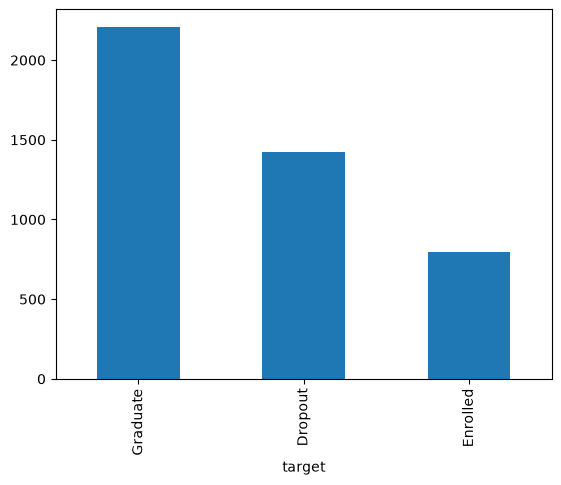

In [32]:
std_groups = students["target"].value_counts()
std_groups.plot(kind="bar")
plt.show()

In [33]:
students["target"].value_counts()

target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

**Conclusion**

We have imbalanced classes in target group, and it means that to prepare our number close to real world we need to balance our classes. I've decided to start from SMOTE library to balance classes

### 4. Oversampling using SMOTE

In [34]:
sm = SMOTE(random_state = 1, sampling_strategy='auto')

In [35]:
X_train_smote, y_train_smote =  sm.fit_resample(X_train, y_train)

In [36]:
gb_classif_smote = GradientBoostingClassifier(max_depth = 3,
                                   n_estimators = 100, 
                                    learning_rate = 0.1)

In [37]:
gb_classif_smote.fit(X_train_smote, y_train_smote)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [38]:
y_pred_test_gb_smote = gb_classif_smote.predict(X_test)
y_pred_train_gb_smote = gb_classif_smote.predict(X_train)

print(f"accuracy {accuracy_score(y_test, y_pred_test_gb_smote)*100: .2f}")
print(f"accuracy_train {accuracy_score(y_train, y_pred_train_gb_smote)*100: .2f}")

print(f"recall {recall_score(y_test, y_pred_test_gb_smote, average='macro'): .2f}")
print(f"F1-score {f1_score(y_test, y_pred_test_gb_smote, average='macro'): .2f}")
print(f"Precision_score {precision_score(y_test, y_pred_test_gb_smote, average='macro'): .2f}")

accuracy  71.19
accuracy_train  76.04
recall  0.68
F1-score  0.67
Precision_score  0.68


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test_gb_smote))

              precision    recall  f1-score   support

     Dropout       0.82      0.69      0.75       284
    Enrolled       0.39      0.57      0.46       159
    Graduate       0.83      0.78      0.81       442

    accuracy                           0.71       885
   macro avg       0.68      0.68      0.67       885
weighted avg       0.75      0.71      0.72       885



In [40]:
print("Manual tuning ('max_depth': 3, 'n_estimators': 100)")
print(classification_report(y_pred = y_pred_test_m2, y_true = y_test))
print("---")
print("\n")
print("GridSearch ('max_depth': 3, 'n_estimators': 100)")
print(classification_report(y_pred = y_pred_test, y_true = y_test))
print("---")
print("\n")
print("GridSearch ('learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100)")
print(classification_report(y_pred = y_pred_test_1, y_true = y_test))
print("---")
print("\n")
print("GridSearch ('learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 100)")
print(classification_report(y_pred = y_pred_test_2, y_true = y_test))
print("---")
print("\n")
print("Class balance (SMOTE) ('learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 100)")
print(classification_report(y_pred = y_pred_test_gb_smote, y_true = y_test))


Manual tuning ('max_depth': 3, 'n_estimators': 100)
              precision    recall  f1-score   support

     Dropout       0.77      0.76      0.76       284
    Enrolled       0.56      0.33      0.42       159
    Graduate       0.78      0.90      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.67       885
weighted avg       0.74      0.76      0.74       885

---


GridSearch ('max_depth': 3, 'n_estimators': 100)
              precision    recall  f1-score   support

     Dropout       0.77      0.76      0.76       284
    Enrolled       0.56      0.33      0.42       159
    Graduate       0.78      0.90      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.67       885
weighted avg       0.74      0.76      0.74       885

---


GridSearch ('learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100)
              precision    recall  f1-score   support


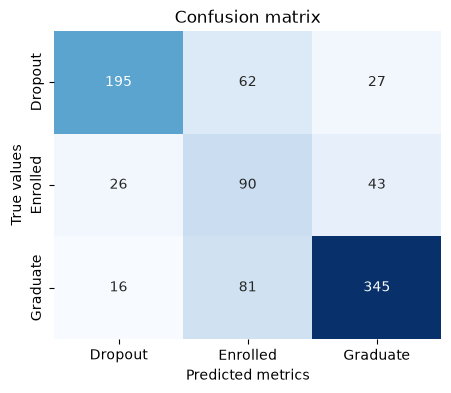

In [44]:
cm = confusion_matrix(y_test, y_pred_test_gb_smote, labels=["Dropout", "Enrolled", "Graduate"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
           xticklabels=["Dropout", "Enrolled", "Graduate"],
           yticklabels=["Dropout", "Enrolled", "Graduate"])
plt.xlabel('Predicted metrics')
plt.ylabel('True values')
plt.title('Confusion matrix')
plt.show()

**Conclusion**

1. Using GridSearch, we defined the most effective set of parameters:
    - increasing of 'learning_rate' raises the probability of model overfitting
    - increasing 'max_depth' > 3 raises the probability of model overfitting too
    - **the most effective combination for the GradientBoostingClassifier model: 'learning_rate': 0.10 (default), 'max_depth': 3, 'n_estimators': 100** 
2. Initially, the classes in the target column were unbalanced. This could potentially lead to inflated metrics. Therefore, a strategy was chosen to balance the classes using a 'SMOTE' library
    - SMOTE reduced overall accuracy form 0.75 to 0.71 but improved macro recall and F1-score from 0.67 to 0.68 - metrics that weigh prediction quality equally across all classes, including the least represented one (Enrolled).
  
Given the project's objective, we need to identify at-risk students (those at risk of expulsion) as early as possible, even at the cost of a slightly higher false-positive rate for the Graduate class. The model using SMOTE is preferable, despite its lower accuracy